imports

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.io import read_image
from sklearn.metrics import confusion_matrix

In [4]:
train_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(),
        transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])
transform=transforms.Compose([
    transforms.ToTensor(),
        transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])
train_dataset=datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)
test_dataset=datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=transform
)

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

Files already downloaded and verified
Files already downloaded and verified


In [5]:
train_loader=DataLoader(train_dataset, shuffle=True, batch_size=64)
test_loader=DataLoader(test_dataset, shuffle=False, batch_size=64)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.696086].


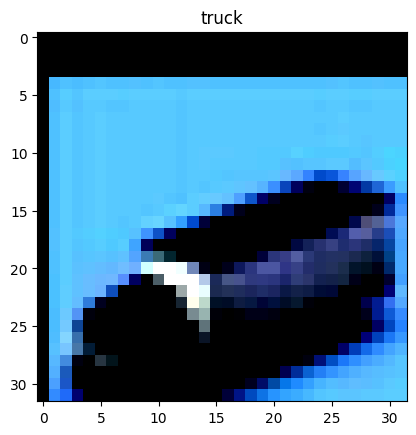

In [6]:
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1,2,0))
plt.title(classes[labels[0]])
plt.show()

In [7]:
class CNNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone=nn.Sequential(
            nn.Conv2d(3,16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32,32,kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,128,kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,10)

        )
    
    def forward(self, x):
        x=self.backbone(x)
        x=self.classifier(x)
        return x
        

In [8]:
device=torch.device('cuda')
model=CNNmodel().to(device)
criteration=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)


In [9]:
for epoch in range(30):
    runningloss=0
    for images,labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        prediction=model(images)
        loss=criteration(prediction,labels)
        loss.backward()
        optimizer.step()
        runningloss+=loss.item()
    batchloss=runningloss/len(train_loader)
    print(f'epoch: {epoch+1}/30')
    print(f'loss: {batchloss}')

epoch: 1/30
loss: 1.5840788477522028
epoch: 2/30
loss: 1.2105117161255663
epoch: 3/30
loss: 1.0598828042559612
epoch: 4/30
loss: 0.966683803007121
epoch: 5/30
loss: 0.8833401865895142
epoch: 6/30
loss: 0.8295648170401678
epoch: 7/30
loss: 0.7761836070615007
epoch: 8/30
loss: 0.7390261937285323
epoch: 9/30
loss: 0.7063366193753069
epoch: 10/30
loss: 0.6826074223612886
epoch: 11/30
loss: 0.6616429135851238
epoch: 12/30
loss: 0.6329923783193159
epoch: 13/30
loss: 0.6160897073881401
epoch: 14/30
loss: 0.5960531427008112
epoch: 15/30
loss: 0.5754637724488897
epoch: 16/30
loss: 0.5621015783351706
epoch: 17/30
loss: 0.5445199827937519
epoch: 18/30
loss: 0.5359208035613875
epoch: 19/30
loss: 0.5201253730355931
epoch: 20/30
loss: 0.5008064438314999
epoch: 21/30
loss: 0.4938630762193209
epoch: 22/30
loss: 0.4769661983146387
epoch: 23/30
loss: 0.4740519716840266
epoch: 24/30
loss: 0.4656428677956467
epoch: 25/30
loss: 0.4512248340889316
epoch: 26/30
loss: 0.4440120876673847
epoch: 27/30
loss: 0.4

Test Accuracy: 82.54%


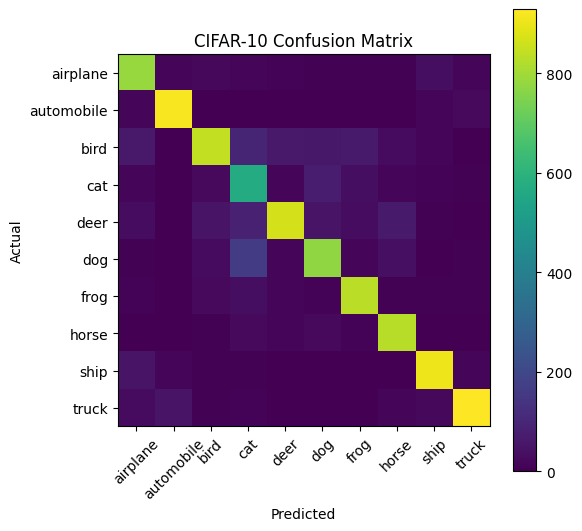

In [23]:
model.eval()
total=0
correct=0
all_preds=[]
all_labels=[]
with torch.no_grad():
    for images, labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy=100*correct/total

print(f"Test Accuracy: {accuracy:.2f}%")
cm=confusion_matrix(all_preds, all_labels)
plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(10),
classes,rotation=45)
plt.yticks(
    range(10),
    classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CIFAR-10 Confusion Matrix")
plt.show()
    

In [ ]:

image=read_image("./plane.png")
model=model.to(device)
model.eval()
transofrmed=transforms.Compose(
    [
        transforms.Resize((32,32)),
        transforms.ConvertImageDtype(torch.float),

        transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616))
    ]
)
timg=transofrmed(image)
timg=timg.to(device).unsqueeze(0)
print(timg.shape)
softmax=nn.Softmax(dim=1)
predict=softmax(model(timg))
print(predict)
classs=torch.argmax(predict, dim=1).item()
print(classes[classs])

torch.Size([1, 3, 32, 32])
tensor([[4.4093e-11, 6.7867e-12, 1.4927e-14, 1.0808e-13, 1.9159e-17, 1.0546e-14,
         1.1964e-16, 3.1322e-14, 2.1767e-15, 1.0000e+00]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
truck
